In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
clean_df = pd.read_csv("../data/bangla_music_clean.csv")
clean_df.head()

,file_name,zero_crossing,spectral_centroid,spectral_rolloff,spectral_bandwidth,chroma_frequency,rmse,delta,melspectogram,tempo,...,mfcc12,mfcc13,mfcc14,mfcc15,mfcc16,mfcc17,mfcc18,mfcc19,label,tempo_category
0,(Tomake Paowa) - Hridoy Khan & Tasnim Anika F...,125424,1770.889394,3893.575094,2414.810615,0.315795,0.222552,-7.661680e-08,12.977708,172.265625,...,-3.867179,5.325016,1.176338,-0.788755,-6.343288,2.488148,0.047027,7.211918,adhunik,Very Fast
1,008. Jai Bole Jete Naire - Jewel (1980).mp3,308658,2549.349989,4986.658880,2193.617981,0.310113,0.156930,8.893313e-08,5.118271,143.554688,...,-12.691169,11.393858,-6.176215,9.947330,-6.987708,7.935905,-9.452455,1.582699,adhunik,Very Fast
2,03. Doob Habib ft Mousumi & Mosharraf Karim...,158328,2013.718396,4573.595848,2515.994413,0.301663,0.093736,1.340824e-07,2.497263,103.359375,...,-6.730814,0.184162,-4.139533,4.409801,3.190835,4.862090,-6.406590,-0.705287,adhunik,Moderate
3,034. Mukhe Bolo Valobashi by Muni Kis.mp3,136711,1827.495303,4215.075766,2284.762196,0.349875,0.039457,-1.908483e-08,0.421975,135.999178,...,-7.990767,3.611352,-4.211268,5.490051,-7.556331,1.124302,-4.306443,0.957663,adhunik,Fast
4,05. Abar elo Je Shondha by Happy Akhand.mp3,238711,1715.832235,3303.949296,1587.488472,0.300132,0.142870,-5.355904e-08,4.311442,92.285156,...,-5.323076,-3.194775,-7.124155,-4.431173,-4.797250,-4.686700,-4.393025,-1.749295,adhunik,Moderate


In [4]:
clean_df.dtypes

file_name                 str
zero_crossing           int64
spectral_centroid     float64
spectral_rolloff      float64
spectral_bandwidth    float64
chroma_frequency      float64
rmse                  float64
delta                 float64
melspectogram         float64
tempo                 float64
mfcc0                 float64
mfcc1                 float64
mfcc2                 float64
mfcc3                 float64
mfcc4                 float64
mfcc5                 float64
mfcc6                 float64
mfcc7                 float64
mfcc8                 float64
mfcc9                 float64
mfcc10                float64
mfcc11                float64
mfcc12                float64
mfcc13                float64
mfcc14                float64
mfcc15                float64
mfcc16                float64
mfcc17                float64
mfcc18                float64
mfcc19                float64
label                     str
tempo_category            str
dtype: object

In [5]:
# Correlation table
features = [
    "tempo",
    "rmse",
    "zero_crossing",
    "spectral_centroid",
    "spectral_rolloff",
    "spectral_bandwidth",
    "chroma_frequency"
]

clean_df[features].corr().round(2)

,tempo,rmse,zero_crossing,spectral_centroid,spectral_rolloff,spectral_bandwidth,chroma_frequency
tempo,1.00,-0.08,0.02,-0.04,-0.05,-0.06,-0.13
rmse,-0.08,1.00,0.03,0.08,0.09,0.09,0.16
zero_crossing,0.02,0.03,1.00,0.84,0.71,0.51,0.40
spectral_centroid,-0.04,0.08,0.84,1.00,0.97,0.88,0.63
spectral_rolloff,-0.05,0.09,0.71,0.97,1.00,0.94,0.67
spectral_bandwidth,-0.06,0.09,0.51,0.88,0.94,1.00,0.66
chroma_frequency,-0.13,0.16,0.40,0.63,0.67,0.66,1.00


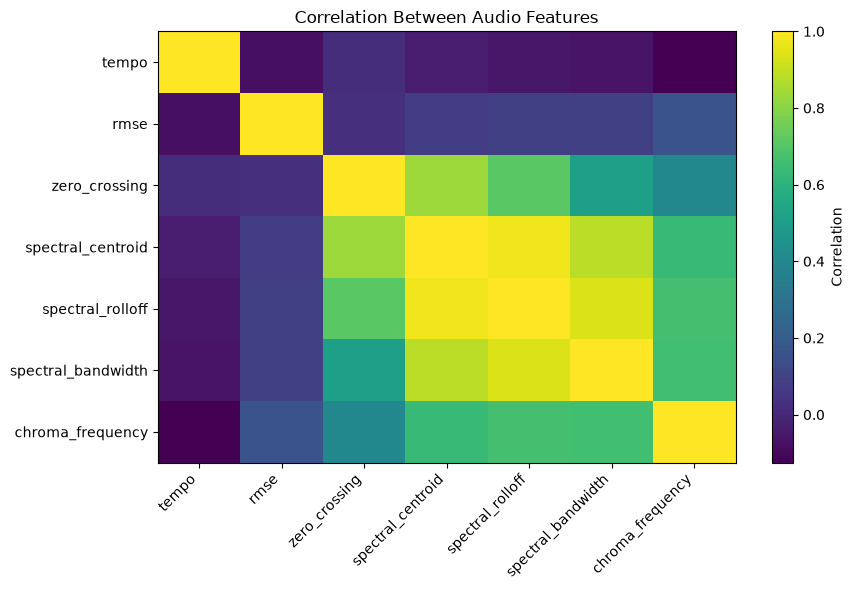

In [6]:
# Correlation heatmap
plt.figure(figsize=(9, 6))
plt.imshow(clean_df[features].corr(), aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(features)), features, rotation=45, ha="right")
plt.yticks(range(len(features)), features)
plt.title("Correlation Between Audio Features")
plt.tight_layout()
plt.show()

The heatmap shows several spectral features are strongly related, especially spectral_centroid and spectral_rolloff, spectral_rolloff and spectral_bandwidth, and zero_crossing and spectral_centroid. 
That means some features may measure similar aspects of sound.

In [7]:
#Create clearer genre-level averages:
genre_features = (
    clean_df.groupby("label")[features]
    .mean()
    .round(2)
)

genre_features

,tempo,rmse,zero_crossing,spectral_centroid,spectral_rolloff,spectral_bandwidth,chroma_frequency
label,,,,,,,
adhunik,119.84,0.18,179833.67,2004.76,4313.33,2326.16,0.31
band,127.03,0.16,275995.72,2585.10,5396.12,2513.22,0.36
hiphop,112.96,0.21,225064.01,2436.97,5194.41,2512.78,0.39
nazrul,124.16,0.17,184407.72,1363.60,2449.74,1236.30,0.24
palligeeti,125.13,0.17,261663.74,2233.45,4414.39,2111.88,0.28
rabindra,129.57,0.14,169258.16,1536.54,2983.17,1629.95,0.25


In [12]:
pip install scikit-learn

^C
Note: you may need to restart the kernel to use updated packages.


In [13]:
#Standardize the features so different scales can be compared:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_values = scaler.fit_transform(
    genre_features
)

genre_features_scaled = pd.DataFrame(
    scaled_values,
    index=genre_features.index,
    columns=genre_features.columns
)

genre_features_scaled


[notice] A new release of pip is available: 25.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached scikit_learn-1.9.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached narwhals-2.24.0-py3-none-any.whl.metadata (15 kB)
Using cached scikit_learn-1.9.0-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached narwhals-2.24.0-py3-none-any.whl (461 kB)

   ---------------------------------------- 0/3 [narwhals]
   ---------------------------------------- 0/3 [narwhals]
   ---------------------------------------- 0/3 [narwhals]
   ---------------------------------------- 0/3 [narwhals]
   ---------------------------------------- 0/3 [narwhals]
   ---------------------------------------- 0/3 [narwhals]
   ---------------------------------------- 0/3 [narwhals]
   ---------------------------------------- 0/3 [narwhals]
   ---------------------------------------- 0/3 [narwhals]
   ---------------------------------------- 0/3 [narwhals]
   ---------------------------

,tempo,rmse,zero_crossing,spectral_centroid,spectral_rolloff,spectral_bandwidth,chroma_frequency
label,,,,,,,
adhunik,-0.604694,0.394055,-0.875591,-0.049074,0.174319,0.572141,0.090909
band,0.722863,-0.551677,1.450114,1.246816,1.177586,0.966904,1.000000
hiphop,-1.875012,1.812654,0.218317,0.916044,0.990690,0.965975,1.545455
nazrul,0.192948,-0.078811,-0.764967,-1.480773,-1.552403,-1.727848,-1.181818
palligeeti,0.372048,-0.078811,1.103491,0.461587,0.267957,0.119935,-0.454545
rabindra,1.191846,-1.497410,-1.131363,-1.094601,-1.058150,-0.897107,-1.000000


  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ----------------------------------- ---- 7.3/8.3 MB 39.1 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 31.9 MB/s  0:00:00
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   ------- -------------------------------- 7.3/37.3 MB 38.2 MB/s eta 0:00:01
   --------------------- ------------------ 20.2/37.3 MB 50.5 MB/s eta 0:00:01
   -------------------------------------- - 35.9/37.3 MB 58.9 MB/s eta 0:00:01
   ---------------------------------------- 37.3/37.3 MB 47.3 MB/s  0:00:00
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- -------------------------------

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'c:\\Users\\scmkb\\OneDrive\\Desktop\\Sur\\.venv\\Lib\\site-packages\\sklearn\\_cyutility.cp314-win_amd64.pyd'
Check the permissions.


[notice] A new release of pip is available: 25.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


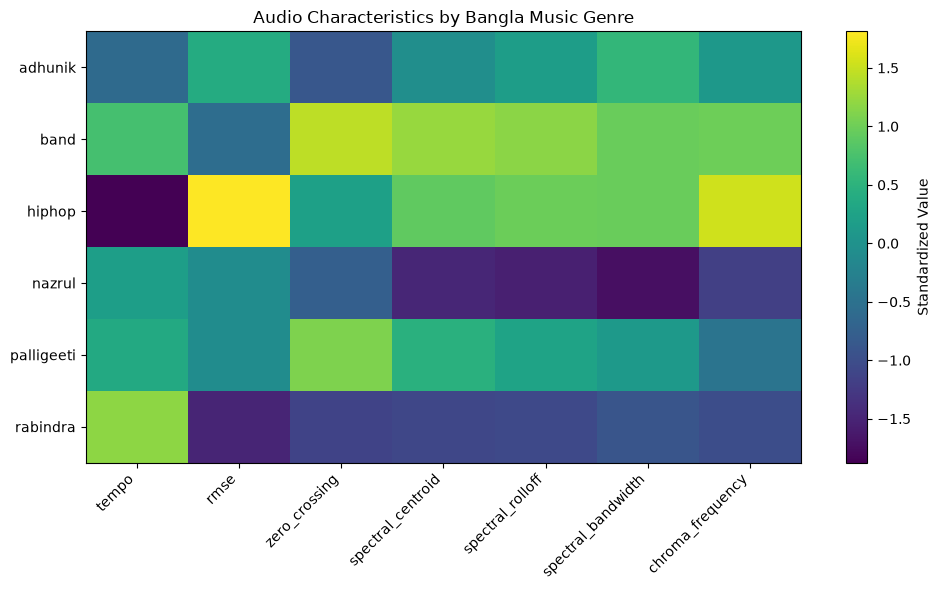

In [14]:
# Genre comparison heatmap
plt.figure(figsize=(10, 6))
plt.imshow(genre_features_scaled, aspect="auto")
plt.colorbar(label="Standardized Value")
plt.xticks(
    range(len(genre_features_scaled.columns)),
    genre_features_scaled.columns,
    rotation=45,
    ha="right"
)
plt.yticks(
    range(len(genre_features_scaled.index)),
    genre_features_scaled.index
)
plt.title("Audio Characteristics by Bangla Music Genre")
plt.tight_layout()
plt.show()

Hip-hop: highest loudness (rmse) and high chroma.
Band: strongest high-frequency/spectral characteristics.
Rabindra: fastest average tempo but softer and lower spectral values.
Nazrul: lower spectral brightness and bandwidth.
Palligeeti: relatively high zero-crossing and moderate spectral values.

In [15]:
genre_features.reset_index().to_csv(
    "../data/genre_summary.csv",
    index=False
)

print("Genre summary saved!")

Genre summary saved!


In [16]:
profile = genre_features.copy()

profile["tempo_rank"] = profile["tempo"].rank(ascending=False)
profile["loudness_rank"] = profile["rmse"].rank(ascending=False)
profile["brightness_rank"] = profile["spectral_centroid"].rank(ascending=False)

profile.round(2)

,tempo,rmse,zero_crossing,spectral_centroid,spectral_rolloff,spectral_bandwidth,chroma_frequency,tempo_rank,loudness_rank,brightness_rank
label,,,,,,,,,,
adhunik,119.84,0.18,179833.67,2004.76,4313.33,2326.16,0.31,5.0,2.0,4.0
band,127.03,0.16,275995.72,2585.10,5396.12,2513.22,0.36,2.0,5.0,1.0
hiphop,112.96,0.21,225064.01,2436.97,5194.41,2512.78,0.39,6.0,1.0,2.0
nazrul,124.16,0.17,184407.72,1363.60,2449.74,1236.30,0.24,4.0,3.5,6.0
palligeeti,125.13,0.17,261663.74,2233.45,4414.39,2111.88,0.28,3.0,3.5,3.0
rabindra,129.57,0.14,169258.16,1536.54,2983.17,1629.95,0.25,1.0,6.0,5.0


In [17]:
#Find the brightest songs:
clean_df[
    ["file_name", "label", "spectral_centroid"]
].sort_values(
    "spectral_centroid",
    ascending=False
).head(10)

,file_name,label,spectral_centroid
1315,amar bondhure koi pabo shokhi go.mp3,palligeeti,5323.086970
314,04. Azam Khan- Saleka Maleka.mp3,band,4473.705333
346,07. Hasan - Jodi Kokhono.mp3,band,4214.636374
379,100. Prometheus - Piya.mp3,band,4161.003462
1499,"064. Ogo Kishor Aji - Debabrata Biswas, Suchit...",rabindra,4115.267706
462,23. Hasan - Tomari Ashay.mp3,band,4106.757612
337,063. Maqsoodul Haque - Ektu Porei.mp3,band,4099.029889
1335,Bangla Folk Song By Ferdousi R. Agee Janlee T...,palligeeti,4084.777604
1276,14. BHAWAIYA GAAN TAPRA AJU.mp3,palligeeti,4023.483239
1370,Ferdousi Rahman - O Amar Darodi Age Janle Tor...,palligeeti,3996.997420


In [18]:
#Find the loudest songs:
clean_df[
    ["file_name", "label", "rmse"]
].sort_values(
    "rmse",
    ascending=False
).head(10)

,file_name,label,rmse
1424,PAGOL MON MON RA MON KANO ETO KOTHA BOLA BAJ...,palligeeti,0.628826
545,46. Warfaze - Keu nei Eka live.mp3,band,0.620491
1268,12. Mor barite jayen tumra o sonar bondudhan b...,palligeeti,0.593709
1332,babu selammm bare.mp3,palligeeti,0.585615
874,01 Modir o shopne.mp3,nazrul,0.533022
882,02 Photlo na.mp3,nazrul,0.532023
890,03 Bhorer howa.mp3,nazrul,0.517023
919,06 Mora dake lo.mp3,nazrul,0.513839
154,Hridoy Amar Bangladesh - Arfin Rumey ft Habib ...,adhunik,0.503444
911,05 Keno dile a.mp3,nazrul,0.495146


In [19]:
#Create a simple energy category:
clean_df["energy_category"] = pd.qcut(
    clean_df["rmse"],
    q=3,
    labels=["Low Energy", "Medium Energy", "High Energy"]
)

In [20]:
#Check energy by genre:
pd.crosstab(
    clean_df["label"],
    clean_df["energy_category"],
    normalize="index"
).mul(100).round(1)

energy_category,Low Energy,Medium Energy,High Energy
label,,,
adhunik,20.5,45.6,33.9
band,35.6,37.3,27.1
hiphop,13.9,28.1,58.0
nazrul,34.0,30.4,35.6
palligeeti,36.9,34.2,28.8
rabindra,58.9,24.9,16.2


Hip-hop is clearly the highest-energy genre, while Rabindra songs are mostly low-energy in this dataset.

In [21]:
clean_df.to_csv("../data/bangla_music_enriched.csv", index=False)

In [22]:
#Create a combined genre summary:
final_summary = (
    clean_df.groupby("label")
    .agg(
        song_count=("file_name", "count"),
        average_tempo=("tempo", "mean"),
        average_rmse=("rmse", "mean"),
        average_brightness=("spectral_centroid", "mean")
    )
    .round(2)
)

final_summary

,song_count,average_tempo,average_rmse,average_brightness
label,,,,
adhunik,283,119.84,0.18,2004.76
band,295,127.03,0.16,2585.10
hiphop,295,112.96,0.21,2436.97
nazrul,312,124.16,0.17,1363.60
palligeeti,260,125.13,0.17,2233.45
rabindra,297,129.57,0.14,1536.54


In [23]:
#Create an energy percentage table:
energy_summary = pd.crosstab(
    clean_df["label"],
    clean_df["energy_category"],
    normalize="index"
).mul(100).round(1)

energy_summary

energy_category,Low Energy,Medium Energy,High Energy
label,,,
adhunik,20.5,45.6,33.9
band,35.6,37.3,27.1
hiphop,13.9,28.1,58.0
nazrul,34.0,30.4,35.6
palligeeti,36.9,34.2,28.8
rabindra,58.9,24.9,16.2


In [24]:
#Save both summaries:
final_summary.reset_index().to_csv(
    "../data/final_genre_summary.csv",
    index=False
)

energy_summary.reset_index().to_csv(
    "../data/energy_summary.csv",
    index=False
)